In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('Newversion.csv')
df.head()

,Dst Port,Protocol,Timestamp,FlowDuration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,6,15-02-2018 9.27,6010454,4,4,285,972,285,0,...,32,0.0,0.0,0,0,0.0,0.0,0.0,0.0,DoS attacks-GoldenEye
1,80,6,15-02-2018 9.27,6005042,4,4,422,662,422,0,...,32,0.0,0.0,0,0,0.0,0.0,0.0,0.0,DoS attacks-GoldenEye
2,80,6,15-02-2018 9.27,6003639,4,4,548,972,548,0,...,32,0.0,0.0,0,0,0.0,0.0,0.0,0.0,DoS attacks-GoldenEye
3,80,6,15-02-2018 9.27,5998377,4,4,327,972,327,0,...,32,0.0,0.0,0,0,0.0,0.0,0.0,0.0,DoS attacks-GoldenEye
4,80,6,15-02-2018 9.27,5999806,4,4,378,972,378,0,...,32,0.0,0.0,0,0,0.0,0.0,0.0,0.0,DoS attacks-GoldenEye


In [ ]:
df.describe()

,Dst Port,Protocol,FlowDuration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,855341.000000,855341.000000,8.553410e+05,855341.000000,855341.000000,8.553410e+05,8.553410e+05,855341.000000,855341.000000,855341.000000,...,855341.000000,855341.000000,8.553410e+05,8.553410e+05,8.553410e+05,8.553410e+05,8.553410e+05,8.553410e+05,8.553410e+05,8.553410e+05
mean,5431.872985,7.987147,1.095784e+07,242.706270,6.097067,7.968478e+03,4.403586e+03,157.074950,8.566407,41.233195,...,239.361576,22.150894,9.494578e+04,3.662108e+04,1.398449e+05,7.187080e+04,4.528170e+06,2.198083e+05,4.782006e+06,4.328006e+06
std,14359.688230,4.347566,2.949133e+07,5423.533055,154.216447,1.738662e+05,2.237110e+05,242.999147,26.978419,55.151687,...,5423.339279,9.995421,1.002841e+06,4.995905e+05,1.296641e+06,8.691879e+05,1.658111e+07,2.064718e+06,1.707573e+07,1.643581e+07
min,0.000000,0.000000,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,53.000000,6.000000,2.570000e+02,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,...,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.000000,6.000000,9.984000e+03,2.000000,1.000000,3.600000e+01,5.200000e+01,34.000000,0.000000,27.812500,...,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,445.000000,6.000000,1.818170e+06,4.000000,4.000000,3.260000e+02,4.880000e+02,266.000000,0.000000,67.500000,...,1.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65533.000000,17.000000,1.200000e+08,309629.000000,38418.000000,9.908128e+06,5.606950e+07,2920.000000,1460.000000,1808.419048,...,309628.000000,44.000000,1.084622e+08,6.027822e+07,1.084622e+08,1.084622e+08,1.200000e+08,7.493599e+07,1.200000e+08,1.200000e+08


In [ ]:
df.isnull().sum().sum()

1870

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 855341 entries, 0 to 855340
Data columns (total 80 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Dst Port           855341 non-null  int64  
 1   Protocol           855341 non-null  int64  
 2   Timestamp          855341 non-null  object 
 3   FlowDuration       855341 non-null  int64  
 4   Tot Fwd Pkts       855341 non-null  int64  
 5   Tot Bwd Pkts       855341 non-null  int64  
 6   TotLen Fwd Pkts    855341 non-null  int64  
 7   TotLen Bwd Pkts    855341 non-null  int64  
 8   Fwd Pkt Len Max    855341 non-null  int64  
 9   Fwd Pkt Len Min    855341 non-null  int64  
 10  Fwd Pkt Len Mean   855341 non-null  float64
 11  Fwd Pkt Len Std    855341 non-null  float64
 12  Bwd Pkt Len Max    855341 non-null  int64  
 13  Bwd Pkt Len Min    855341 non-null  int64  
 14  Bwd Pkt Len Mean   855341 non-null  float64
 15  Bwd Pkt Len Std    855341 non-null  float64
 16  Fl

In [ ]:
# Find columns with NaN values
columns_with_nan = df.columns[df.isnull().any()].tolist()

# Find rows with NaN values in the entire DataFrame
rows_with_nan = df[df.isnull().any(axis=1)]

# Print columns with NaN values
print("Columns with NaN values:")
print(columns_with_nan)
# Print rows with NaN values
if not rows_with_nan.empty:
    print("\nRows with NaN values:")
    print(rows_with_nan)
else:
    print("\nNo rows with NaN values found.")

Columns with NaN values:
['Flow Byts/s']

Rows with NaN values:
        Dst Port  Protocol         Timestamp  FlowDuration  Tot Fwd Pkts  \
255593     51524         6   01-03-2018 2.00             0             2   
255693     53227         6   01-03-2018 2.00             0             2   
255883     53557         6   01-03-2018 2.01             0             2   
255886     53562         6   01-03-2018 2.01             0             2   
256141     53389         6   01-03-2018 2.01             0             2   
...          ...       ...               ...           ...           ...   
849001       135         6   22-02-2018 5.29             0             2   
849058     52533         6   22-02-2018 4.41             0             2   
851532     50519         6  22-02-2018 10.58             0             2   
852484     50693         6  22-02-2018 11.25             0             2   
854462     50465         6  22-02-2018 10.49             0             2   

        Tot Bwd Pkts  T

In [ ]:
import pandas as pd

# Drop rows with NaN values
df_cleaned = df.dropna()
df_cleaned.to_csv('cleaned_dataset.csv', index=False)
df1=pd.read_csv('cleaned_dataset.csv')


In [ ]:
df1.isnull().sum().sum()

0

In [ ]:
for i in df1.columns:
    print(i)
    print(df1[i].value_counts())

Dst Port
Dst Port
80       237890
53       150516
21       100210
443       68653
3389      64121
          ...  
12370         1
58560         1
42846         1
41502         1
64601         1
Name: count, Length: 28003, dtype: int64
Protocol
Protocol
6     686105
17    159052
0       8314
Name: count, dtype: int64
Timestamp
Timestamp
16-02-2018 1.45     50000
21-02-2018 2.12     11764
21-02-2018 2.11     10824
21-02-2018 2.17     10708
21-02-2018 2.31      9521
                    ...  
14-02-2018 10.54        1
17-02-2018 10.15        1
15-02-2018 10.02        1
14-02-2018 11.11        1
14-02-2018 1.43         1
Name: count, Length: 1149, dtype: int64
FlowDuration
FlowDuration
2            47859
1            21632
3            20959
6             8926
7             6836
             ...  
6469393          1
53544979         1
123402           1
119965062        1
2013403          1
Name: count, Length: 345552, dtype: int64
Tot Fwd Pkts
Tot Fwd Pkts
1         273267
2         240702

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 853471 entries, 0 to 853470
Data columns (total 80 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Dst Port           853471 non-null  int64  
 1   Protocol           853471 non-null  int64  
 2   Timestamp          853471 non-null  object 
 3   FlowDuration       853471 non-null  int64  
 4   Tot Fwd Pkts       853471 non-null  int64  
 5   Tot Bwd Pkts       853471 non-null  int64  
 6   TotLen Fwd Pkts    853471 non-null  int64  
 7   TotLen Bwd Pkts    853471 non-null  int64  
 8   Fwd Pkt Len Max    853471 non-null  int64  
 9   Fwd Pkt Len Min    853471 non-null  int64  
 10  Fwd Pkt Len Mean   853471 non-null  float64
 11  Fwd Pkt Len Std    853471 non-null  float64
 12  Bwd Pkt Len Max    853471 non-null  int64  
 13  Bwd Pkt Len Min    853471 non-null  int64  
 14  Bwd Pkt Len Mean   853471 non-null  float64
 15  Bwd Pkt Len Std    853471 non-null  float64
 16  Fl

In [ ]:
import pandas as pd

# List of column names to remove
columns_to_remove = ['Timestamp', 'Bwd PSH Flags', 'Fwd PSH Flags','Fwd URG Flags','Bwd URG Flags','FIN Flag Cnt','CWE Flag Count','Fwd Byts/b Avg','Fwd Blk Rate Avg','Bwd Byts/b Avg','Bwd Pkts/b Avg','Bwd Blk Rate Avg']  # Replace with your actual column names

# Remove the specified columns
df1 = df1.drop(columns=columns_to_remove)
df1.info()
# Now 'df1' contains the dataset with the specified columns removed


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 853471 entries, 0 to 853470
Data columns (total 68 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Dst Port           853471 non-null  int64  
 1   Protocol           853471 non-null  int64  
 2   FlowDuration       853471 non-null  int64  
 3   Tot Fwd Pkts       853471 non-null  int64  
 4   Tot Bwd Pkts       853471 non-null  int64  
 5   TotLen Fwd Pkts    853471 non-null  int64  
 6   TotLen Bwd Pkts    853471 non-null  int64  
 7   Fwd Pkt Len Max    853471 non-null  int64  
 8   Fwd Pkt Len Min    853471 non-null  int64  
 9   Fwd Pkt Len Mean   853471 non-null  float64
 10  Fwd Pkt Len Std    853471 non-null  float64
 11  Bwd Pkt Len Max    853471 non-null  int64  
 12  Bwd Pkt Len Min    853471 non-null  int64  
 13  Bwd Pkt Len Mean   853471 non-null  float64
 14  Bwd Pkt Len Std    853471 non-null  float64
 15  Flow Byts/s        853471 non-null  float64
 16  Fl

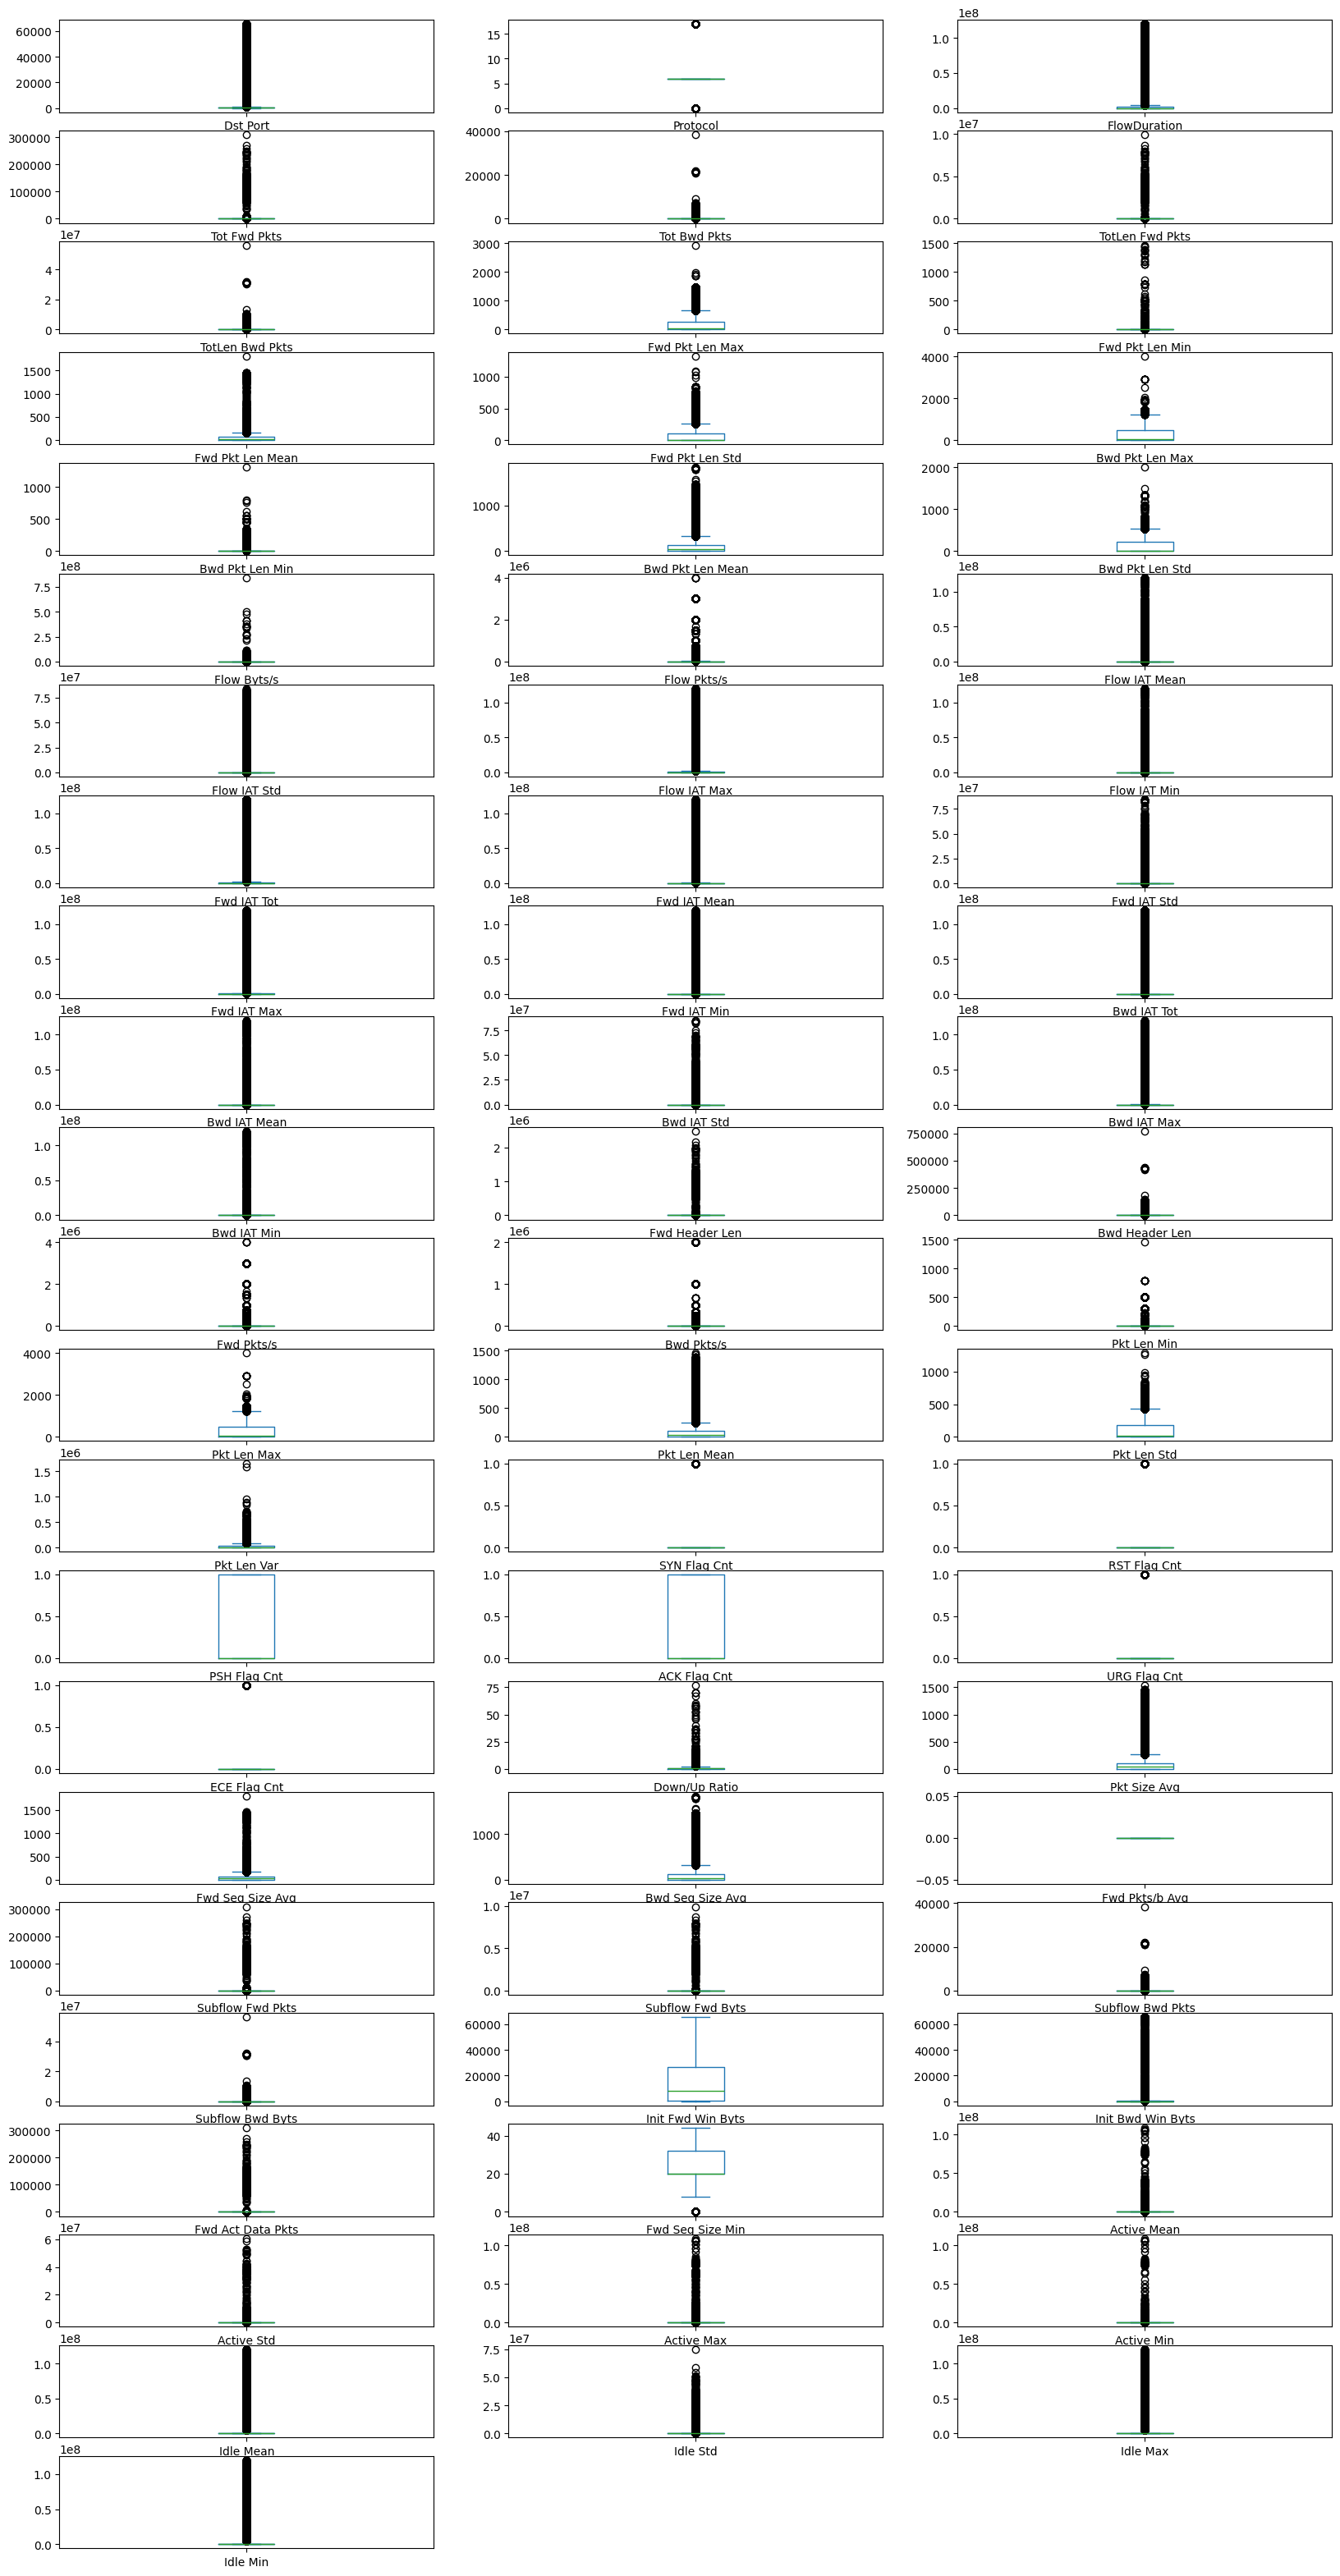

In [ ]:
df1.plot(kind='box',subplots=True,layout=(23,3),figsize=(20,40))
plt.show()

<Axes: >

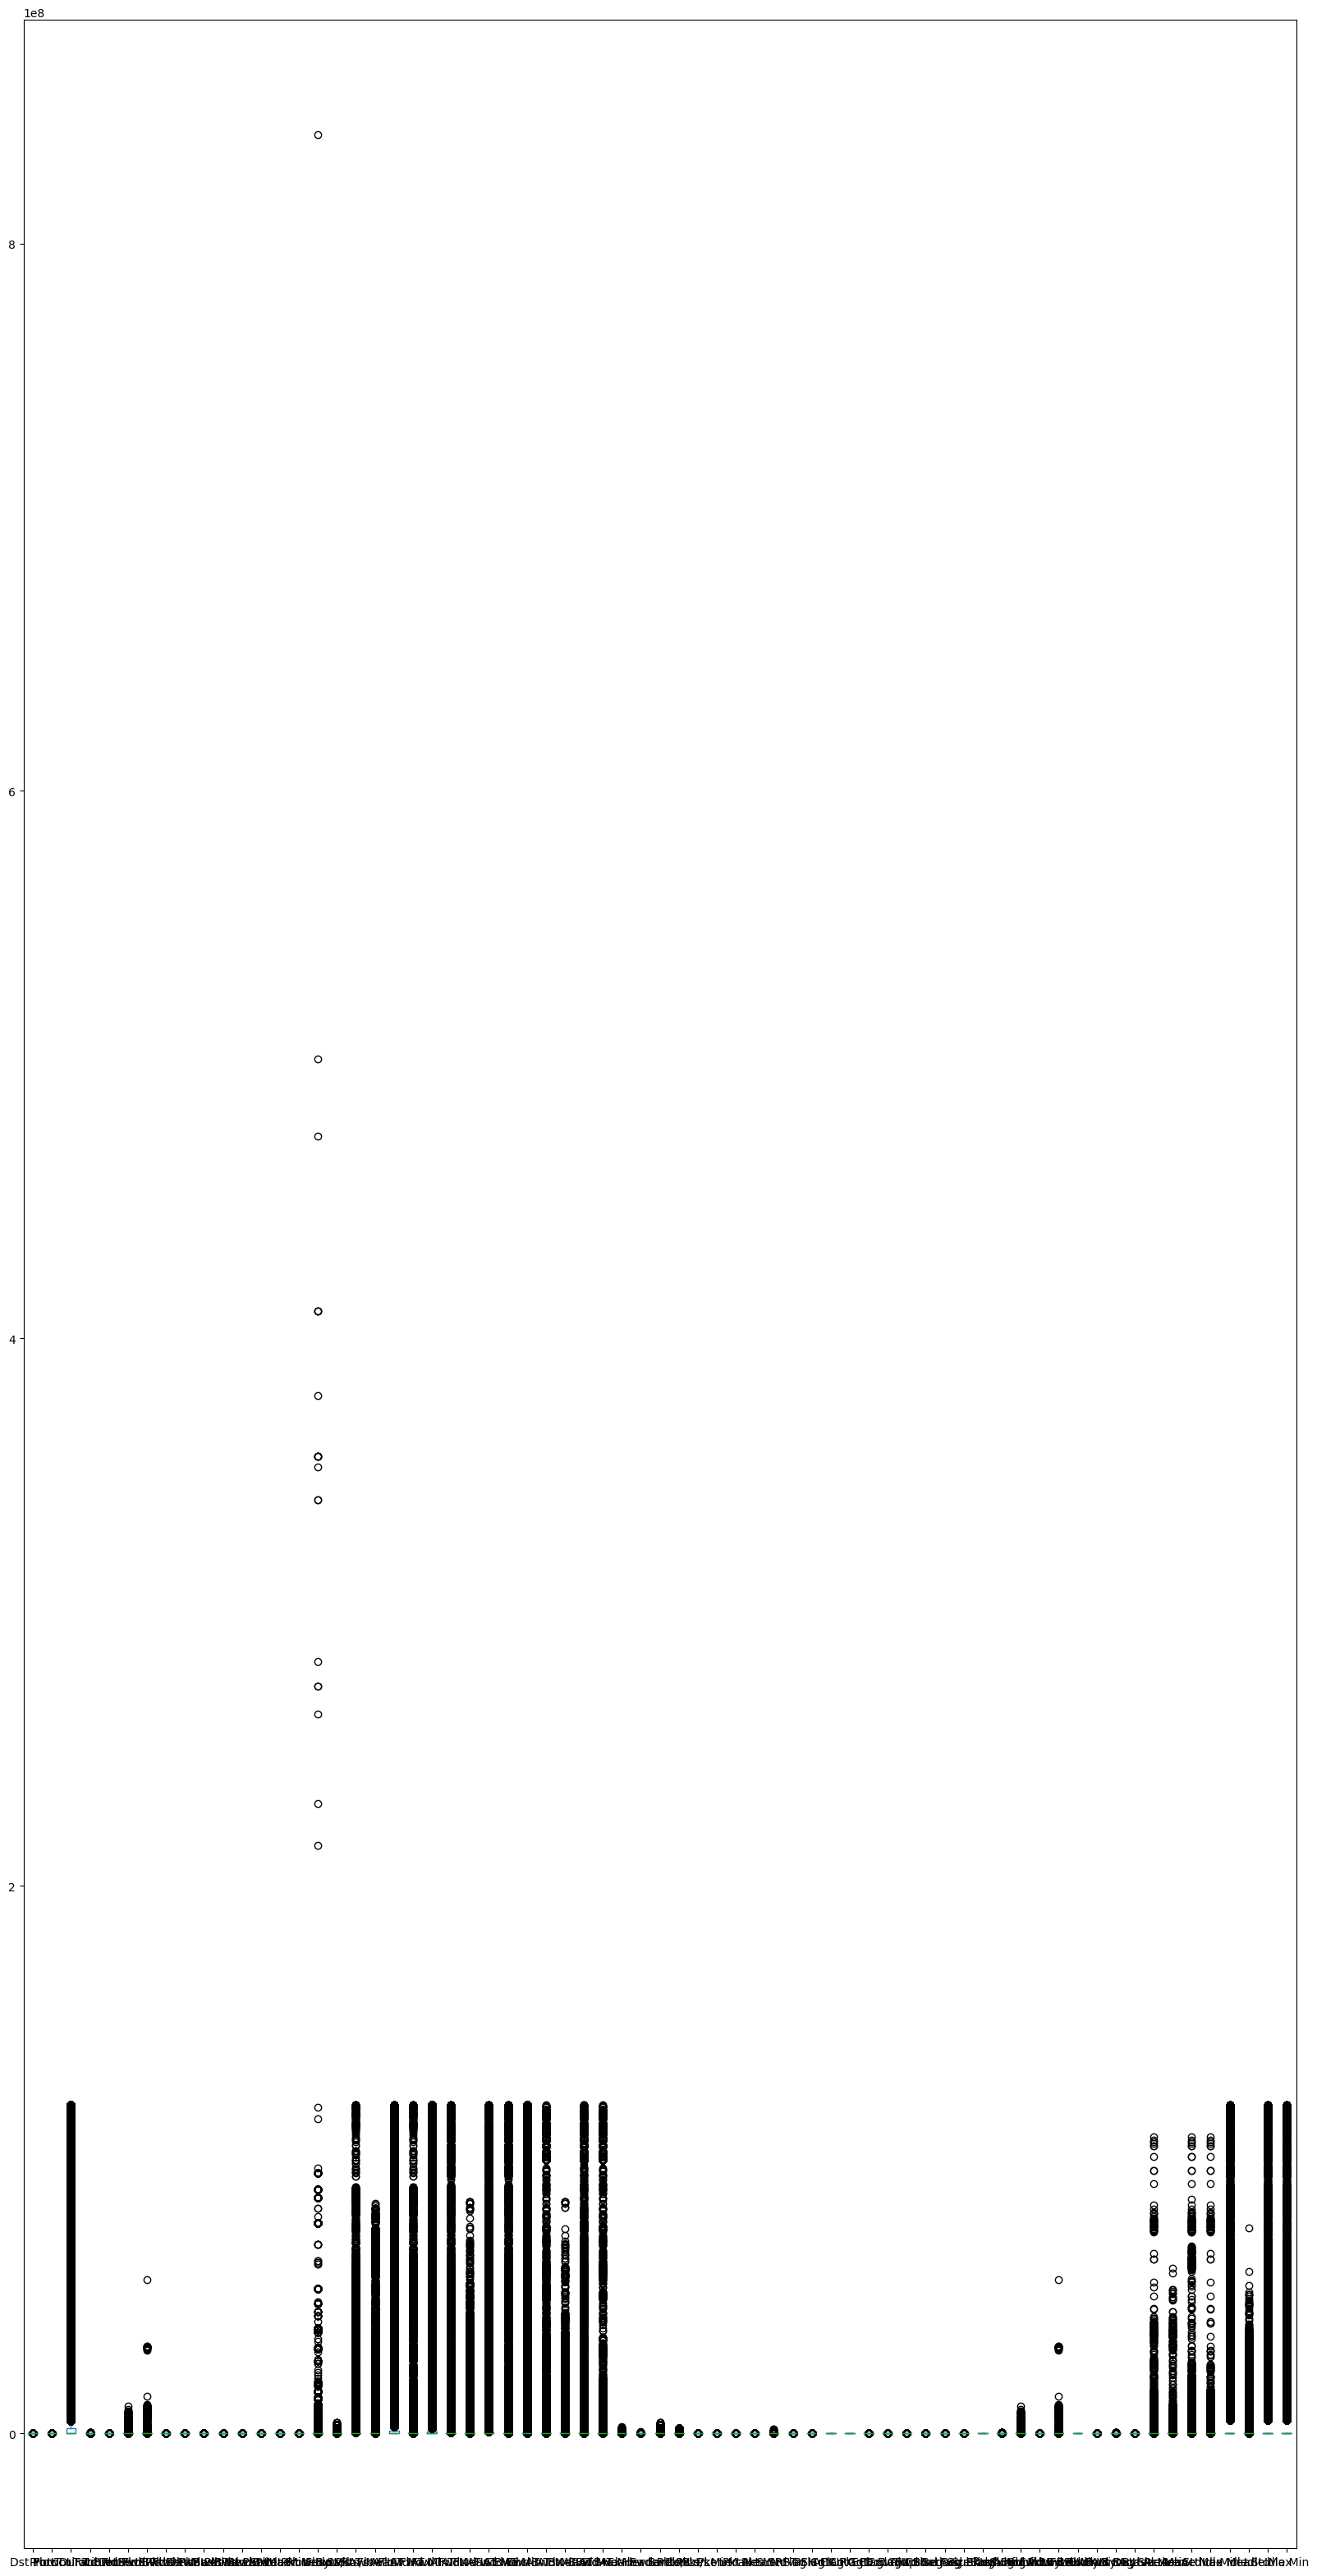

In [ ]:
df1.plot(kind='box', subplots=False, figsize=(20,40))


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns in the dataset
categorical_columns = df1.select_dtypes(include=['object']).columns

# Create a LabelEncoder instance
label_encoder = LabelEncoder()

# Apply LabelEncoder to each categorical column
for column in categorical_columns:
    df1[column] = label_encoder.fit_transform(df1[column])

# Print the dataset with encoded categorical values
df1.to_csv('stage1.csv',index=False)
df2=pd.read_csv('stage1.csv')
df2['Label'].value_counts()

Label
0     447828
4      52683
10     50185
8      50000
7      50000
1      50000
11     49747
13     48438
6      41508
9      10990
5       1730
2        249
3         79
12        34
Name: count, dtype: int64

In [ ]:
df2.isnull().sum().sum()

0

In [ ]:
df2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 853471 entries, 0 to 853470
Data columns (total 68 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Dst Port           853471 non-null  int64  
 1   Protocol           853471 non-null  int64  
 2   FlowDuration       853471 non-null  int64  
 3   Tot Fwd Pkts       853471 non-null  int64  
 4   Tot Bwd Pkts       853471 non-null  int64  
 5   TotLen Fwd Pkts    853471 non-null  int64  
 6   TotLen Bwd Pkts    853471 non-null  int64  
 7   Fwd Pkt Len Max    853471 non-null  int64  
 8   Fwd Pkt Len Min    853471 non-null  int64  
 9   Fwd Pkt Len Mean   853471 non-null  float64
 10  Fwd Pkt Len Std    853471 non-null  float64
 11  Bwd Pkt Len Max    853471 non-null  int64  
 12  Bwd Pkt Len Min    853471 non-null  int64  
 13  Bwd Pkt Len Mean   853471 non-null  float64
 14  Bwd Pkt Len Std    853471 non-null  float64
 15  Flow Byts/s        853471 non-null  float64
 16  Fl

In [ ]:
df2['Label'] = df2['Label'].apply(lambda x: 1 if x != 0 else x)
df2.isnull().sum().sum()

0

In [ ]:
df2.head()

,Dst Port,Protocol,FlowDuration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,6,6010454,4,4,285,972,285,0,71.25,...,32,0.0,0.0,0,0,0.0,0.0,0.0,0.0,1
1,80,6,6005042,4,4,422,662,422,0,105.50,...,32,0.0,0.0,0,0,0.0,0.0,0.0,0.0,1
2,80,6,6003639,4,4,548,972,548,0,137.00,...,32,0.0,0.0,0,0,0.0,0.0,0.0,0.0,1
3,80,6,5998377,4,4,327,972,327,0,81.75,...,32,0.0,0.0,0,0,0.0,0.0,0.0,0.0,1
4,80,6,5999806,4,4,378,972,378,0,94.50,...,32,0.0,0.0,0,0,0.0,0.0,0.0,0.0,1


In [ ]:
df2=pd.read_csv('stage1.csv')
# List of feature names  to be included in the new dataset
selected_features = ['Bwd Pkt Len Std' ,  'PSH Flag Cnt' , 'Fwd Seg Size Min' ,  'Bwd Pkt Len Min' , 'ACK Flag Cnt' , 'Fwd IAT Std' , 'Init Fwd Win Byts', 'Flow IAT Max'  ,   'Bwd Pkts/s' ,  'Bwd IAT Tot'   , 'URG Flag Cnt' ,  'Pkt Len Min' , 'Label']

# Create a new dataset with selected features
df2_new = df2[selected_features]
df2_new['Label'] = df2['Label'].apply(lambda x: 1 if x != 0 else x)

# Save the new dataset to a CSV file
df2_new.to_csv('new_dataset.csv', index=False)

# Read the new dataset to check if it was created successfully
df2_new1 = pd.read_csv('new_dataset.csv')


In [ ]:
df2_new1['Label'].value_counts()

Label
0    447828
1    405643
Name: count, dtype: int64

In [ ]:
df2_new1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 853471 entries, 0 to 853470
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Bwd Pkt Len Std    853471 non-null  float64
 1   PSH Flag Cnt       853471 non-null  int64  
 2   Fwd Seg Size Min   853471 non-null  int64  
 3   Bwd Pkt Len Min    853471 non-null  int64  
 4   ACK Flag Cnt       853471 non-null  int64  
 5   Fwd IAT Std        853471 non-null  float64
 6   Init Fwd Win Byts  853471 non-null  int64  
 7   Flow IAT Max       853471 non-null  float64
 8   Bwd Pkts/s         853471 non-null  float64
 9   Bwd IAT Tot        853471 non-null  float64
 10  URG Flag Cnt       853471 non-null  int64  
 11  Pkt Len Min        853471 non-null  int64  
 12  Label              853471 non-null  int64  
dtypes: float64(5), int64(8)
memory usage: 84.6 MB


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
# Load your dataset from a CSV file
file_path = 'new_dataset.csv'

# Load dataset
df = pd.read_csv(file_path)

# Check for constant columns and remove them
non_constant_columns = df.columns[df.nunique() > 1]
df = df[non_constant_columns]

# Check for infinite values and replace them with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with NaN values
df.dropna(inplace=True)

# Min-Max scaling for numeric columns (int64 and float64)
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if numeric_columns:
    scaler = MinMaxScaler()
    df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

# Display the scaled dataset
df.to_csv('df.csv',index=False)
df3=pd.read_csv('df.csv')

In [ ]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 853471 entries, 0 to 853470
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Bwd Pkt Len Std    853471 non-null  float64
 1   PSH Flag Cnt       853471 non-null  float64
 2   Fwd Seg Size Min   853471 non-null  float64
 3   Bwd Pkt Len Min    853471 non-null  float64
 4   ACK Flag Cnt       853471 non-null  float64
 5   Fwd IAT Std        853471 non-null  float64
 6   Init Fwd Win Byts  853471 non-null  float64
 7   Flow IAT Max       853471 non-null  float64
 8   Bwd Pkts/s         853471 non-null  float64
 9   Bwd IAT Tot        853471 non-null  float64
 10  URG Flag Cnt       853471 non-null  float64
 11  Pkt Len Min        853471 non-null  float64
 12  Label              853471 non-null  float64
dtypes: float64(13)
memory usage: 84.6 MB


In [ ]:
df3['Label'].value_counts()

Label
0.0    447828
1.0    405643
Name: count, dtype: int64

In [ ]:
df3['Label'] = df3['Label'].apply(lambda x: 1 if x > 0 else 0)
df3['Label'].value_counts()

Label
0    447828
1    405643
Name: count, dtype: int64

In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

X = df3.drop('Label', axis=1)  # Features
y = df3['Label']  # Target variable

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

mutual_info = mutual_info_classif(X_train, y_train)
mutual_info = pd.Series(mutual_info)
mutual_info.index = X_train.columns
mutual_info.sort_values(ascending=False)

Init Fwd Win Byts    0.471870
Fwd Seg Size Min     0.329270
Flow IAT Max         0.310792
Bwd Pkts/s           0.269264
Bwd Pkt Len Std      0.193605
Bwd IAT Tot          0.161401
Fwd IAT Std          0.135324
Pkt Len Min          0.070637
Bwd Pkt Len Min      0.070427
PSH Flag Cnt         0.067961
ACK Flag Cnt         0.020037
URG Flag Cnt         0.000858
dtype: float64

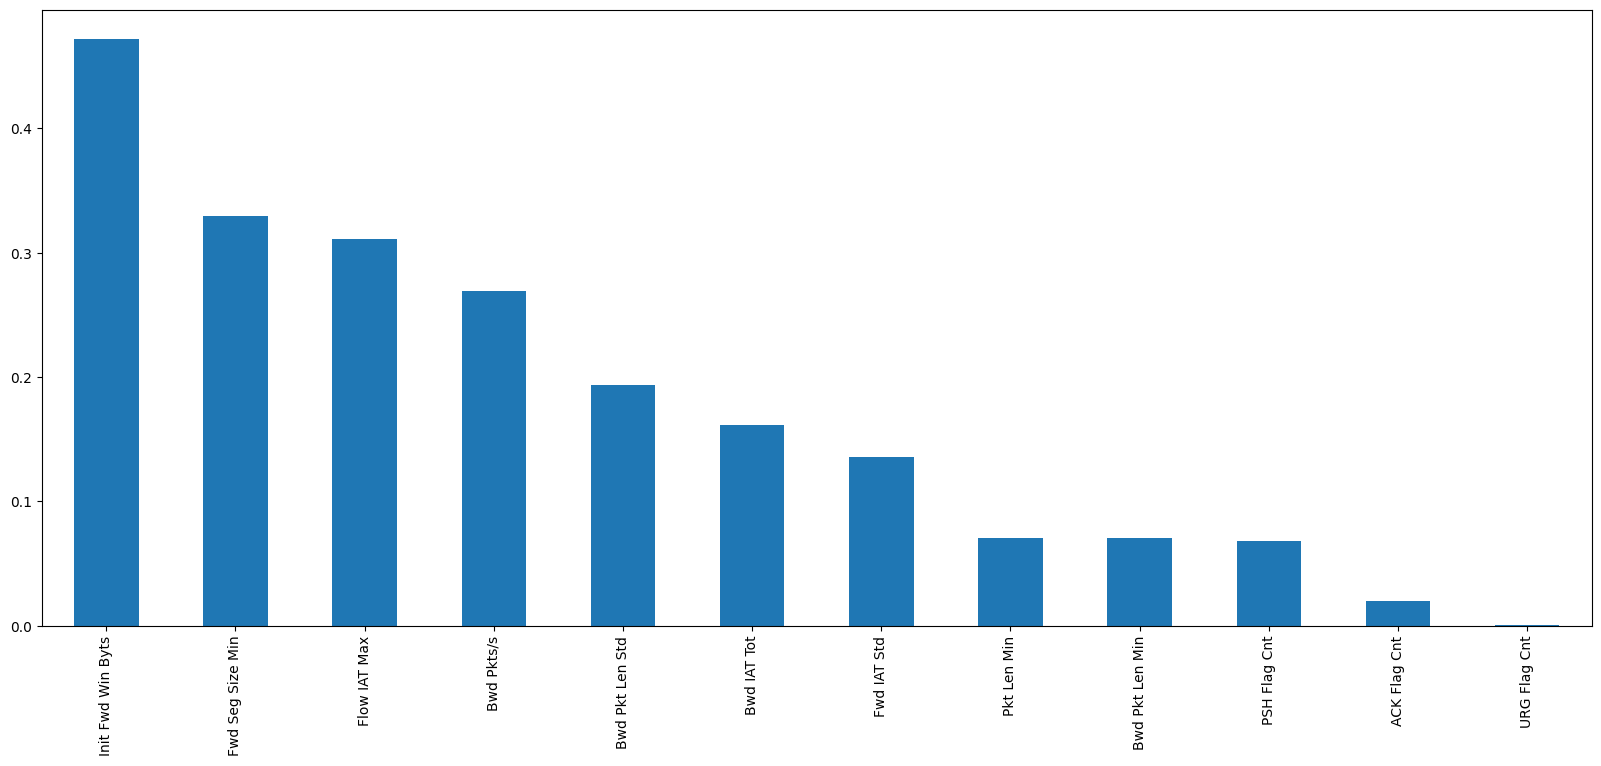

In [ ]:
mutual_info.sort_values(ascending=False).plot.bar(figsize=(20, 8));

In [ ]:
# from sklearn.feature_selection import SelectKBest
# sel_five_cols = SelectKBest(mutual_info_classif, k=20)
# sel_five_cols.fit(X_train, y_train)
# X_train.columns[sel_five_cols.get_support()]

In [ ]:
# col=['Dst Port', 'FlowDuration', 'Fwd Pkt Len Mean', 'Bwd Pkt Len Mean',
#        'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Max', 'Fwd Header Len',
#        'Fwd Pkts/s', 'Pkt Len Max']
# X_train=X_train[col]
# X_test=X_test[col]

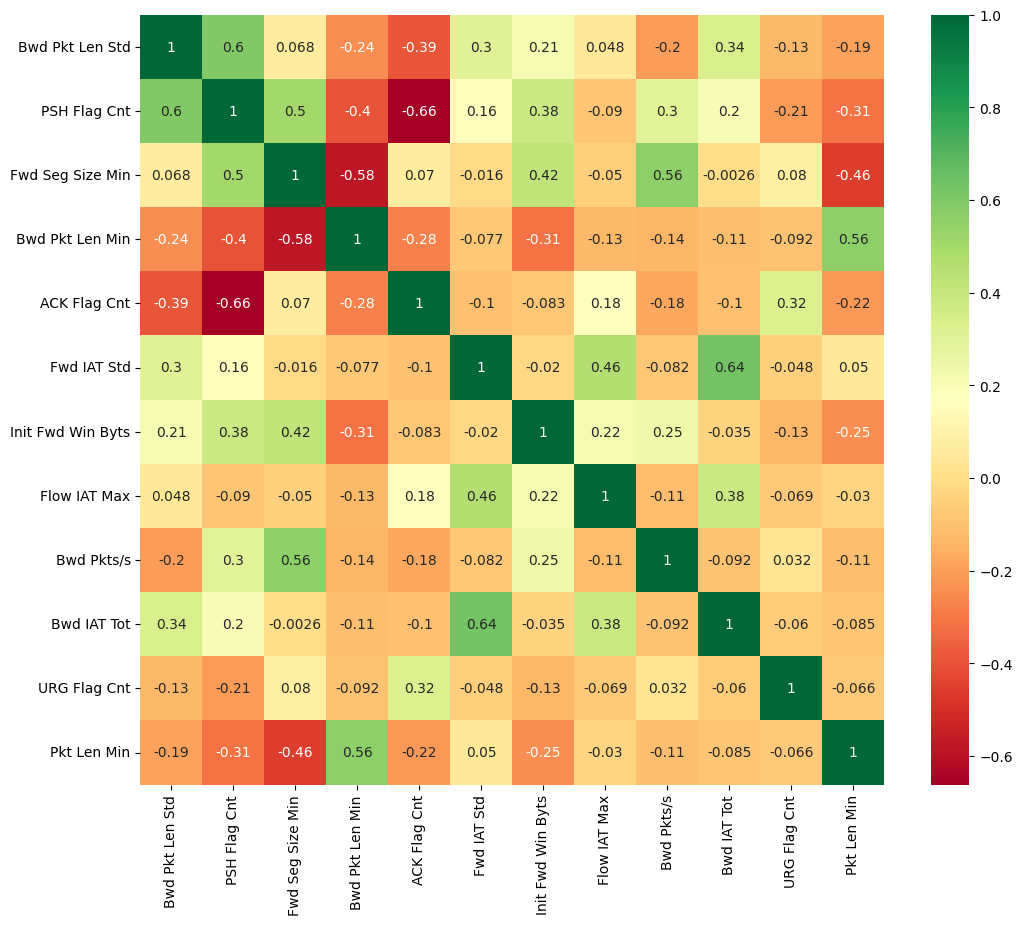

In [ ]:
plt.figure(figsize=(12,10))
p=sns.heatmap(X_train.corr(), annot=True,cmap ='RdYlGn')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score
df3.replace([np.inf, -np.inf], 1e15, inplace=True)

X = df3.drop('Label', axis=1)  # Features
y = df3['Label']  # Target variable

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Initialize the Gaussian Naive Bayes model with regularization (var_smoothing)
gnb = GaussianNB(var_smoothing=1e-9)  # You can experiment with different values

# Train the model on the training set
gnb.fit(X_train, y_train)

# Make predictions on the training set
y_train_pred = gnb.predict(X_train)

# Make predictions on the test set
y_test_pred = gnb.predict(X_test)

# Calculate accuracy and precision on both sets
accuracy_train = accuracy_score(y_train, y_train_pred)
precision_train = precision_score(y_train, y_train_pred, average='weighted')

accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred, average='weighted')

# Print accuracy and precision on both sets
print(f'Training Accuracy: {accuracy_train:.5f}, Training Precision: {precision_train:.5f}')
print(f'Testing Accuracy: {accuracy_test:.5f}, Testing Precision: {precision_test:.5f}')

# Check for overfitting
if accuracy_train - accuracy_test > 0.05 or precision_train - precision_test > 0.05:
    print("The model might be overfitting.")
else:
    print("The model does not seem to be overfitting.")


Training Accuracy: 0.70812, Training Precision: 0.75727
Testing Accuracy: 0.70682, Testing Precision: 0.75691
The model does not seem to be overfitting.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score

X = df3.drop('Label', axis=1)  # Features
y = df3['Label']  # Target variable

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)  # You can adjust hyperparameters

# Train the model on the training set
rf_classifier.fit(X_train, y_train)

# Make predictions on the training set
y_train_pred = rf_classifier.predict(X_train)

# Make predictions on the test set
y_test_pred = rf_classifier.predict(X_test)

# Calculate accuracy and precision on both sets
accuracy_train = accuracy_score(y_train, y_train_pred)
precision_train = precision_score(y_train, y_train_pred, average='weighted')

accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred, average='weighted')

# Print accuracy and precision on both sets
print(f'Training Accuracy: {accuracy_train:.5f}, Training Precision: {precision_train:.5f}')
print(f'Testing Accuracy: {accuracy_test:.5f}, Testing Precision: {precision_test:.5f}')

# Check for overfitting
if accuracy_train - accuracy_test > 0.05 or precision_train - precision_test > 0.05:
    print("The model might be overfitting.")
else:
    print("The model does not seem to be overfitting.")


Training Accuracy: 0.97370, Training Precision: 0.97494
Testing Accuracy: 0.96140, Testing Precision: 0.96339
The model does not seem to be overfitting.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix


X = df3.drop(columns=['Label'])
y = df3['Label']

# Convert categorical labels to integers if needed
# Example: y = pd.factorize(y)[0]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a KNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=20)  # You can adjust the number of neighbors as needed

# Train the model on the training set
knn_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.5f}")
print(f"Precision: {precision:.5f}")

# # Check for overfitting
# if accuracy_train - accuracy_test > 0.05 or precision_train - precision_test > 0.05:
#     print("The model might be overfitting.")
# else:
#     print("The model does not seem to be overfitting.")


Accuracy: 0.96077
Precision: 0.96282


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score

X = df3.drop('Label', axis=1)  # Features
y = df3['Label']  # Target variable

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Initialize the Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters

# Train the model on the training set
dt_classifier.fit(X_train, y_train)

# Make predictions on the training set
y_train_pred = dt_classifier.predict(X_train)

# Make predictions on the test set
y_test_pred = dt_classifier.predict(X_test)

# Calculate accuracy and precision on both sets
accuracy_train = accuracy_score(y_train, y_train_pred)
precision_train = precision_score(y_train, y_train_pred, average='weighted')

accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred, average='weighted')

# Print accuracy and precision on both sets
print(f'Training Accuracy: {accuracy_train:.5f}, Training Precision: {precision_train:.5f}')
print(f'Testing Accuracy: {accuracy_test:.5f}, Testing Precision: {precision_test:.5f}')

# Check for overfitting
if accuracy_train - accuracy_test > 0.05 or precision_train - precision_test > 0.05:
    print("The model might be overfitting.")
else:
    print("The model does not seem to be overfitting.")


Training Accuracy: 0.98535, Training Precision: 0.98572
Testing Accuracy: 0.94917, Testing Precision: 0.94936
The model does not seem to be overfitting.


In [ ]:
# we'll initialize each model and store it by name in a dictionary
model = {}

# Logistic Regression
from sklearn.linear_model import LogisticRegression
model['Logistic Regression'] = LogisticRegression()


# Decision Trees
from sklearn.tree import DecisionTreeClassifier
model['Decision Trees'] = DecisionTreeClassifier(max_depth=3)

# Random Forest
from sklearn.ensemble import RandomForestClassifier
model['Random Forest'] = RandomForestClassifier()

# Naive Bayes
from sklearn.naive_bayes import GaussianNB
model['Naive Bayes'] = GaussianNB()

from sklearn.neighbors import KNeighborsClassifier
model['K-Nearest Neighbor'] = KNeighborsClassifier(n_neighbors=20)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy, precision, recall = {}, {}, {}

for key in model.keys():
    
    # Fit the classifier
    model[key].fit(X_train, y_train)
    
    # Make predictions
    predictions = model[key].predict(X_test)
    
    # Calculate metrics
    accuracy[key] = accuracy_score(predictions, y_test)
    precision[key] = precision_score(predictions, y_test)
    recall[key] = recall_score(predictions, y_test)

In [ ]:
df_model = pd.DataFrame(index=model.keys(), columns=['Accuracy', 'Precision', 'Recall'])
df_model['Accuracy'] = accuracy.values()
df_model['Precision'] = precision.values()
df_model['Recall'] = recall.values()

df_model

,Accuracy,Precision,Recall
Logistic Regression,0.879981,0.773525,0.966535
Decision Trees,0.886282,0.775923,0.979938
Random Forest,0.961402,0.923639,0.994523
Naive Bayes,0.706815,0.913193,0.631945
K-Nearest Neighbor,0.960148,0.921284,0.994197


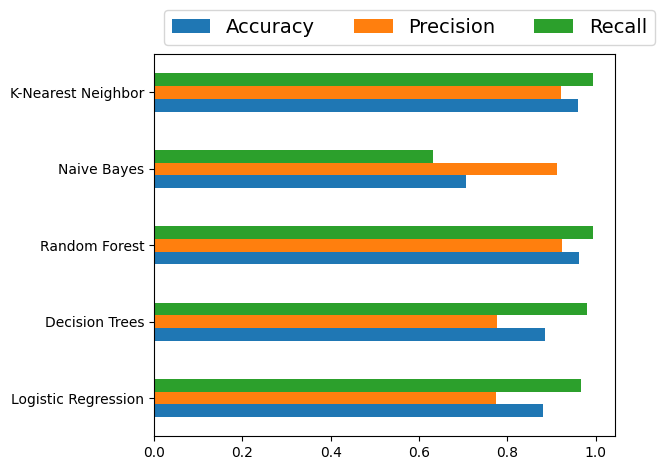

In [ ]:
ax = df_model.plot.barh()
ax.legend(
    ncol=len(model.keys()), 
    bbox_to_anchor=(0, 1), 
    loc='lower left', 
    prop={'size': 14}
)
plt.tight_layout()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()

In [ ]:
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
#print accuracy
print("Accuracy: ",model.score(X_test,y_test) * 100)

Accuracy:  96.12699881952845


In [ ]:
#save the model
import pickle
filename = 'savemodel.sav'
pickle.dump(model, open(filename, 'wb'))

In [ ]:
X_test.head()

,Bwd Pkt Len Std,PSH Flag Cnt,Fwd Seg Size Min,Bwd Pkt Len Min,ACK Flag Cnt,Fwd IAT Std,Init Fwd Win Byts,Flow IAT Max,Bwd Pkts/s,Bwd IAT Tot,URG Flag Cnt,Pkt Len Min
560177,0.214406,1.0,0.454545,0.0,0.0,0.004561,0.125015,7.942742e-03,2.449596e-06,0.011336,0.0,0.0
231009,0.000000,0.0,0.727273,0.0,1.0,0.000000,0.003448,1.731667e-05,0.000000e+00,0.000000,0.0,0.0
211103,0.000000,0.0,0.727273,0.0,1.0,0.000000,0.003448,1.991667e-06,0.000000e+00,0.000000,0.0,0.0
492888,0.000000,1.0,0.909091,0.0,0.0,0.000000,0.410217,1.666667e-08,2.500000e-01,0.000000,0.0,0.0
714503,0.057577,1.0,0.454545,0.0,0.0,0.000418,0.125015,4.261272e-02,3.864406e-07,0.043127,0.0,0.0


In [ ]:
load_model = pickle.load(open(filename,'rb'))

In [ ]:
load_model.predict([[0.214406, 1.0, 0.454545, 0.0, 0.0, 0.004561, 0.125015, 7.942742e-03, 2.449596e-06, 0.011336, 0.0, 0.0]]) 

array([0], dtype=int64)